In [1]:
from resources.cut_off_black_segments import cut_off_black_segments
import nibabel as nib
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

In [2]:
PROJECT_DIR = Path(r"C:\Users\abram\PycharmProjects\DrivenData_DAT_Parkinsons")
NIFTI_DIR = PROJECT_DIR / "data" / "niftis"
FILE_NAME = "09lzrk79.nii.gz"
FILE_PATH = NIFTI_DIR / FILE_NAME

In [3]:
original_img = nib.load(FILE_PATH)
original = original_img.get_fdata(dtype=np.float32)

cropped, _ = cut_off_black_segments(
    path=FILE_PATH,
    threshold=3,
    margin=1,
)

x_max, y_max, z_max = cropped.shape

x = x_max // 2
flat_plain_yz = cropped[x, :, :]

filter_width = 3

filter_y = np.ones((filter_width, z_max))
filter_sum_y = np.zeros(y_max - filter_width + 1)

for y_pos in range(y_max - filter_width + 1):
    area = flat_plain_yz[y_pos:y_pos + filter_width, :]
    filter_sum_y[y_pos] = np.sum(area * filter_y)

filter_width = 3

filter_z = np.ones((y_max, filter_width))
filter_sum_z = np.zeros(z_max - filter_width + 1)

for z_pos in range(z_max - filter_width + 1):
    area = flat_plain_yz[:, z_pos:z_pos + filter_width]
    filter_sum_z[z_pos] = np.sum(area * filter_z)


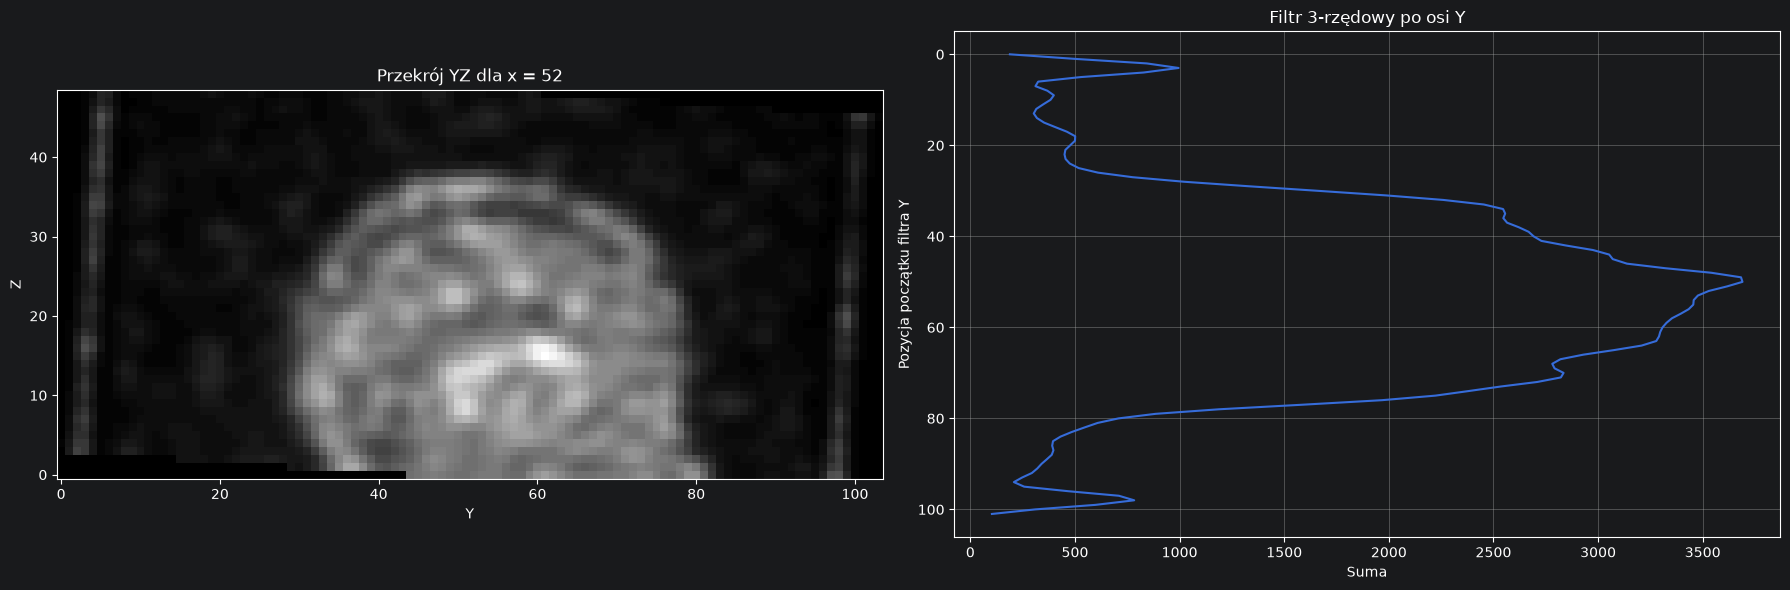

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

axes[0].imshow(flat_plain_yz.T, cmap="gray", origin="lower")
axes[0].set_title(f"Przekrój YZ dla x = {x}")
axes[0].set_xlabel("Y")
axes[0].set_ylabel("Z")

axes[1].plot(filter_sum_y, np.arange(len(filter_sum_y)))
axes[1].invert_yaxis()
axes[1].set_title(f"Filtr {filter_width}-rzędowy po osi Y")
axes[1].set_xlabel("Suma")
axes[1].set_ylabel("Pozycja początku filtra Y")
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [5]:
y = y_max // 2
flat_plain_xz = cropped[:, y, :]

filter_width = 3

filter_x = np.ones((filter_width, z_max))
filter_sum_x = np.zeros(x_max - filter_width + 1)

for x_pos in range(x_max - filter_width + 1):
    area = flat_plain_xz[x_pos:x_pos + filter_width, :]
    filter_sum_x[x_pos] = np.sum(area * filter_x)

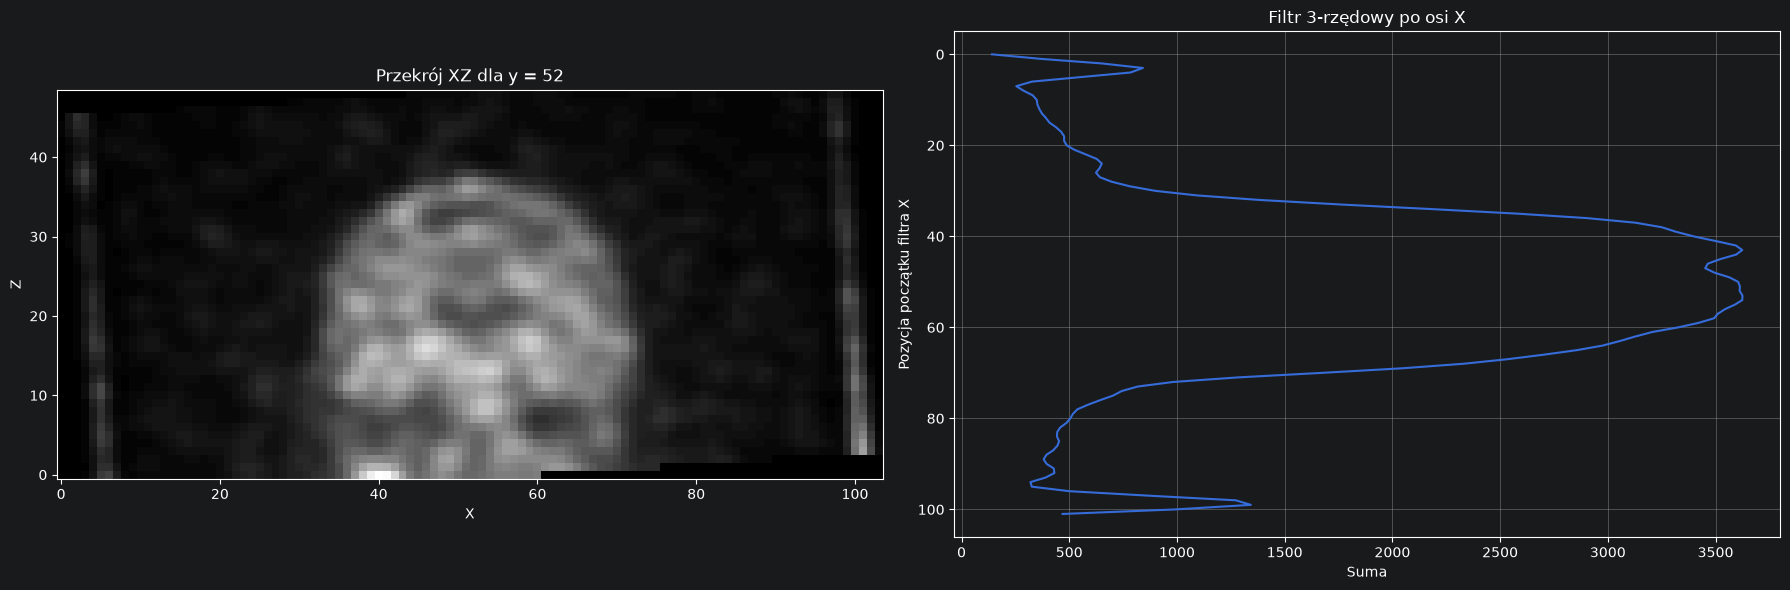

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

axes[0].imshow(flat_plain_xz.T, cmap="gray", origin="lower")
axes[0].set_title(f"Przekrój XZ dla y = {y}")
axes[0].set_xlabel("X")
axes[0].set_ylabel("Z")

axes[1].plot(filter_sum_x, np.arange(len(filter_sum_x)))
axes[1].invert_yaxis()
axes[1].set_title(f"Filtr {filter_width}-rzędowy po osi X")
axes[1].set_xlabel("Suma")
axes[1].set_ylabel("Pozycja początku filtra X")
axes[1].grid(True)

plt.tight_layout()
plt.show()